<a href="https://colab.research.google.com/github/yunju-1118/ESAA/blob/OB/ESAA_OB_week12_2_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **합성곱**

## **전이 학습**

일반적으로 합성곱 신경망 기반의 딥러닝 모델을 제대로 훈련시키려면 많은양의 데이터가 필요하다. 하지만, 큰 데이터셋을 얻는 것은 많은 돈과 시간이 필요하기에 쉽지 않다.

이러한 현실적인 어려움을 해결한 것이 **전이 학습(transfer learning)** 이다. 전이 학습이란 ImageNet처럼 **아주 큰 데이터셋을 써서 훈련된 모델의 가중치를 가져와 우리가 해결하려는 과제에 맞게 보정해서 사용하는 것**을 의미한다. 이때 아주 큰 데이터셋을 사용해 훈련된 모델을 사전 훈련된 모델이라고 한다.

전이 학습을 위한 방법으로는 **특성 추출**과 **미세 조정 기법**이 있다.

### **1. 특성 추출 기법**


**특성 추출(feature extractor)** 은 ImageNet 데이터셋으로 사전 훈련된 모델을 가져온 후 마지막에 완전연결층 부분만 새로 만든다. 즉, 학습할 때는 마지막 완전연결층만 학습하고 나머지 계층들은 학습되지 않도록 한다.

- **합성곱층**: 합성곱층과 풀링층으로 구성
- **데이터 분류기(완전연결층)**: 추출된 특성을 입력받아 최종적으로 이미지에 대한 클래스를 분류하는 부분

사전 훈련된 네트워크의 합성곱층에 새로운 데이터를 통과시키고, 그 출력을 데이터 분류기에서 훈련시킨다.

여기에서 사용 가능한 이미지 분류 모델은 다음과 같다.

- Xception, Inception V3, ResNet50, VGG16, VGG19, MobileNet


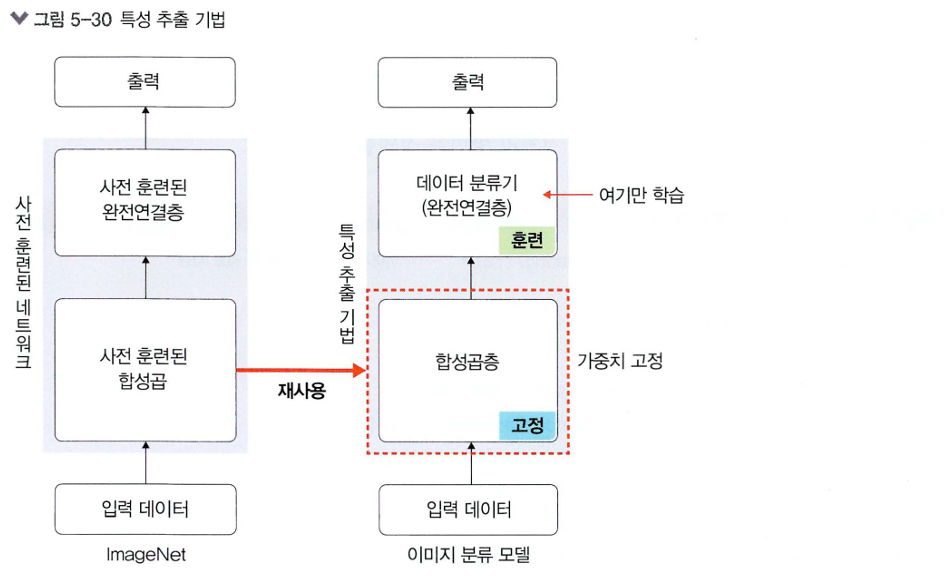

In [2]:
# 라이브러리 호출

import os
import time
import copy
import glob
import cv2
import shutil

import torch
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [9]:
# 이미지 데이터 전처리 방법 정의

data_path = '/content/drive/MyDrive/Colab Notebooks/data/catanddog/train'

transform = transforms.Compose(
    [
        transforms.Resize([256,256]),
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor()
    ]
)

train_dataset = torchvision.datasets.ImageFolder(
    data_path, transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=32,
    num_workers=8,
    shuffle=True
)

print(len(train_dataset))

385


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


1. **torchvision.transform**은 이미지 데이터를 변환하여 모델의 입력으로 사용할 수 있게 변환해준다.
    - **Resize**: 이미지 크기를 조정
    - **RandomResizedCrop**: 이미지를 랜덤한 크기 및 비율로 자름
    - **RandomHorizontalFlip**: 이미지를 랜덤하게 수평으로 뒤집음

2. **datasets.ImageFolder**는 데이터로더가 데이터를 불러올 대상과 방법을 정의한다.

3. **DataLoader**는 데이터를 불러오는 부분으로 앞서 정의한 ImageFolder을 데이터로더에 할당한다.

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 8 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


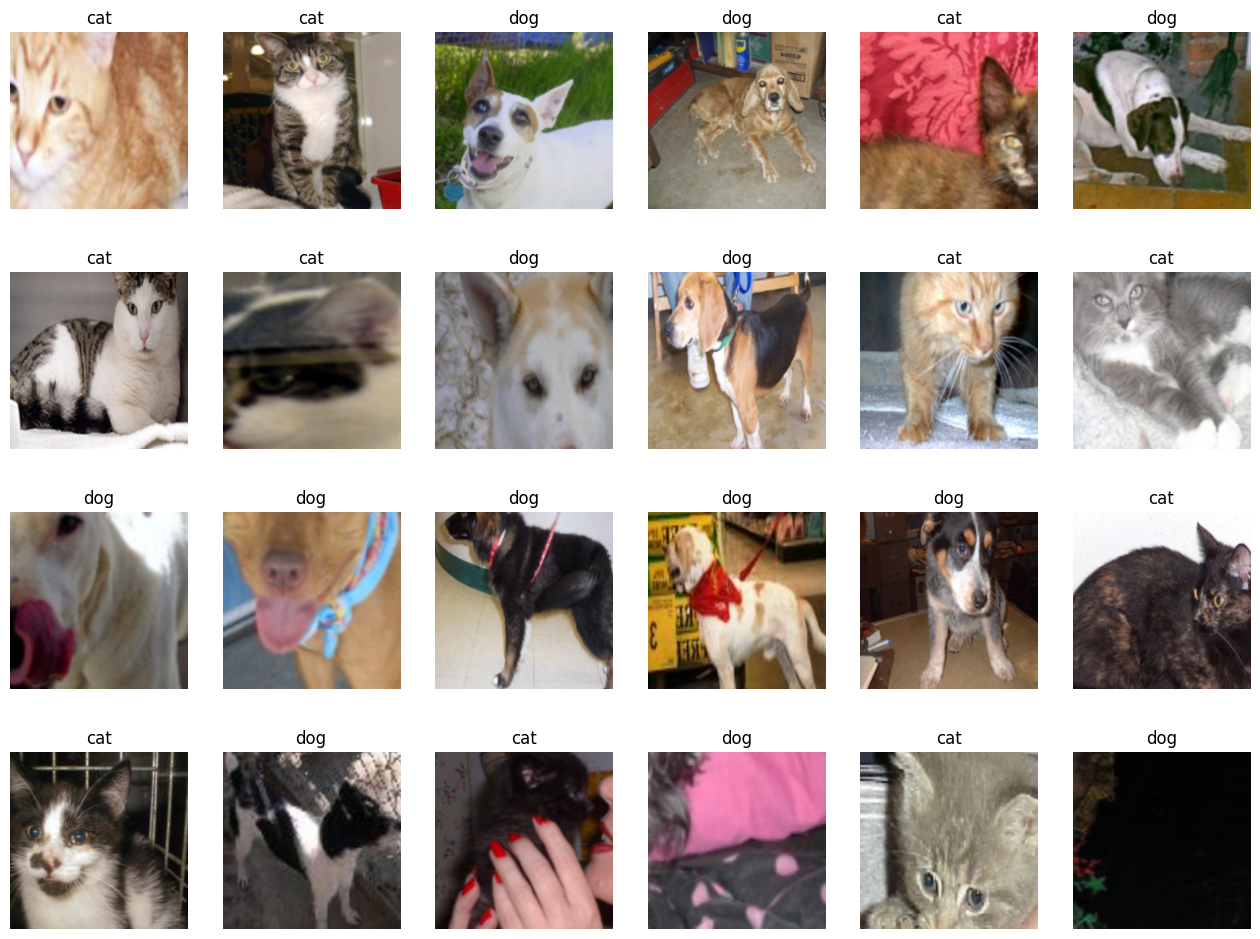

In [10]:
# 학습에 사용될 이미지 출력

import numpy as np

samples, labels = next(iter(train_loader))
classes = {0:'cat', 1:'dog'}
fig = plt.figure(figsize=(16,24))
for i in range(24):
    a = fig.add_subplot(4, 6, i+1)
    a.set_title(classes[labels[i].item()])
    a.axis('off')
    a.imshow(np.transpose(samples[i].numpy(), (1,2,0)))
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

In [11]:
# 사전 훈련된 모델 내려받기

resnet18 = models.resnet18(pretrained=True)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 172MB/s]


**ResNet18**

ResNet18은 50개의 계층으로 구성된 합성곱 신경망입니다. ImageNet 데이터베이스의 100만 개가 넘는 영상을 이용하여 훈련된 신경망으로 전이 학습에 사용되도록 사전 훈련된 모델을 제공하고 있다. 하지만, ResNet18은 입력 제약이 매우 크고, 충분한 메모리가 없으면 학습 속도가 느릴 수 있다는 단점이 있다.

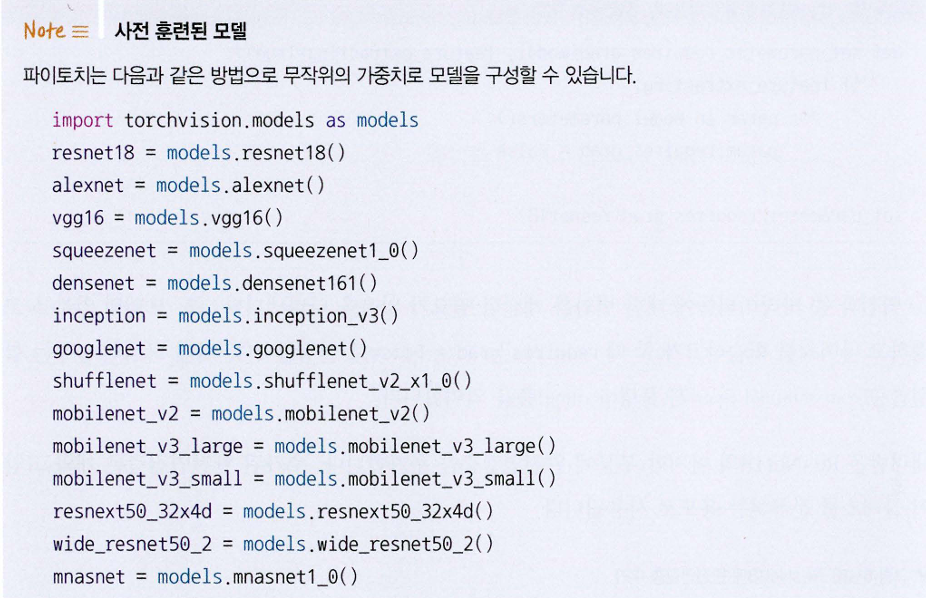

In [12]:
# 사전 훈련된 모델의 파라미터 학습 유무 지정

def set_parameter_requires_grad(model, feature_extracting=True):
    if feature_extracting:
        for param in model.parameters():
            param.requires_grad = False

set_parameter_requires_grad(resnet18)

1. 역전파 중 파라미터들에 대한 변화를 계산할 필요가 없음을 나타낸다. 즉, 모델의 일부를 고정하고 나머지를 학습하고자 할 때 requires_grad = False로 설정한다.

 내려받은 ResNet18의 마지막 부분에 완전연결층을 추가한다. 추가된 완전연결층은 개와 고양이 클래스를 분류하는 용도로 사용된다.

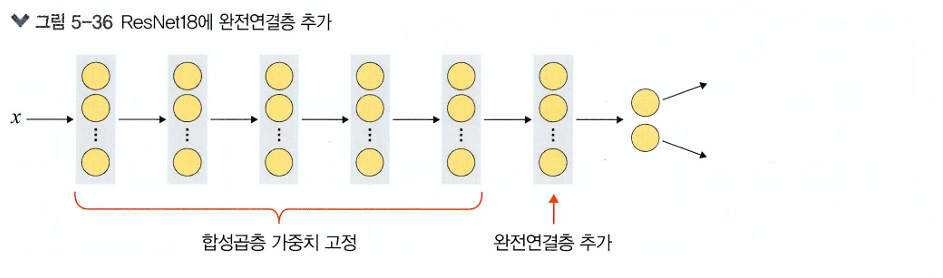

In [13]:
# ResNet18에 완전연결층 추가

resnet18.fc = nn.Linear(512,2)

In [14]:
# 모델의 파라미터 값 확인

for name, param in resnet18.named_parameters():
    if param.requires_grad:
        print(name, param.data)

fc.weight tensor([[ 0.0305, -0.0393, -0.0094,  ..., -0.0084, -0.0179, -0.0432],
        [-0.0210, -0.0247, -0.0291,  ..., -0.0106,  0.0135, -0.0223]])
fc.bias tensor([-0.0235, -0.0335])


In [16]:
# 모델 객체 생성 및 손실 함수 정의

model = models.resnet18(pretrained=True)

for param in model.parameters():
    param.requiers_grad = False

model.fc = torch.nn.Linear(512,2)
for param in model.fc.parameters():
    param.requires_grad = True

optimizer = torch.optim.Adam(model.fc.parameters())
cost = torch.nn.CrossEntropyLoss()
print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [20]:
# 모델 학습을 위한 함수 생성

def train_model(model, dataloaders, criterion, optimizer, device,
                num_epochs=13, is_train=True):
    since = time.time()
    acc_history = []
    loss_history = []
    best_acc = 0.0

    for epoch in range(num_epochs):
        print('Epoch {}/{}'.format(epoch, num_epochs-1))
        print('-'*10)

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            model.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            _, preds = torch.max(outputs, 1)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()*inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(dataloaders.dataset)
        epoch_acc = running_corrects.double() / len(dataloaders.dataset)

        print('Loss: {:.4f}, ACC: {:.4f}'.format(epoch_loss, epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        loss_history.append(epoch_loss)
        torch.save(model.state_dict(),
                   os.path.join('/content/drive/MyDrive/Colab Notebooks/data/catanddog/', '{0:0=2d}.pth'.format(epoch)))
        print()

    time_elapsed = time.time() - since
    print('Training complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed % 60))
    print('Best ACC: {:4f}'.format(best_acc))
    return acc_history, loss_history


In [21]:
# 파라미터 학습 결과를 옵티마이저에 전달

params_to_update = []

for name, param in resnet18.named_parameters():
    if param.requires_grad == True:
        params_to_update.append(param)
        print("\t", name)

optimizer = optim.Adam(params_to_update)

	 fc.weight
	 fc.bias


In [22]:
# 모델 학습

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()
train_acc_hist, train_loss_hist = train_model(resnet18, train_loader, criterion,
                                              optimizer, device)

Epoch 0/12
----------
Loss: 0.5293, ACC: 0.7662

Epoch 1/12
----------
Loss: 0.4161, ACC: 0.8234

Epoch 2/12
----------
Loss: 0.2982, ACC: 0.9117

Epoch 3/12
----------
Loss: 0.2925, ACC: 0.8779

Epoch 4/12
----------
Loss: 0.2411, ACC: 0.9169

Epoch 5/12
----------
Loss: 0.2570, ACC: 0.8987

Epoch 6/12
----------
Loss: 0.2606, ACC: 0.8883

Epoch 7/12
----------
Loss: 0.2238, ACC: 0.9299

Epoch 8/12
----------
Loss: 0.2150, ACC: 0.9169

Epoch 9/12
----------
Loss: 0.1992, ACC: 0.9221

Epoch 10/12
----------
Loss: 0.2216, ACC: 0.9091

Epoch 11/12
----------
Loss: 0.1982, ACC: 0.9273

Epoch 12/12
----------
Loss: 0.1872, ACC: 0.9299

Training complete in 10m 11s
Best ACC: 0.929870


In [23]:
test_path = "/content/drive/MyDrive/Colab Notebooks/data/catanddog/test"

transform = transforms.Compose(
    [
        transforms.Resize(224),
        transforms.CenterCrop(224),
        transforms.ToTensor()
    ]
)

test_dataset = torchvision.datasets.ImageFolder(
    root=test_path, transform=transform
)

test_loader = torch.utils.data.DataLoader(
    test_dataset, batch_size=32, num_workers=1, shuffle=True
)

print(len(test_dataset))

98


In [26]:
# 테스트 데이터 평가 함수 생성

def eval_model(model, dataloaders, device):
    since = time.time()
    acc_history = []
    best_acc = 0.0

    saved_models = glob.glob('/content/drive/MyDrive/Colab Notebooks/data/catanddog/*.pth')
    saved_models.sort()
    print('saved_model', saved_models)

    for model_path in saved_models:
        print('Loading model', model_path)

        model.load_state_dict(torch.load(model_path))
        model.eval()
        model.to(device)
        running_corrects = 0

        for inputs, labels in dataloaders:
            inputs = inputs.to(device)
            labels = labels.to(device)

            with torch.no_grad():
                outputs = model(inputs)

            _, preds = torch.max(outputs.data, 1)
            preds[preds >= 0.5] = 1
            preds[preds < 0.5] = 0
            running_corrects += preds.eq(labels.cpu()).int().sum()

        epoch_acc = running_corrects.double() / len(dataloaders.dataset)
        print('ACC: {:.4f}'.format(epoch_acc))

        if epoch_acc > best_acc:
            best_acc = epoch_acc

        acc_history.append(epoch_acc.item())
        print()

    time_elapsed = time.time() - since
    print('Validation complete in {:.0f}m {:.0f}s'.format(time_elapsed // 60, time_elapsed%60))
    print('Best ACC: {:.4f}'.format(best_acc))

    return acc_history

In [27]:
# 테스트 데이터를 평가 함수에 적용

val_acc_hist = eval_model(resnet18, test_loader, device)

saved_model ['/content/drive/MyDrive/Colab Notebooks/data/catanddog/00.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/01.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/02.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/03.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/04.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/05.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/06.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/07.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/08.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/09.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/10.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/11.pth', '/content/drive/MyDrive/Colab Notebooks/data/catanddog/12.pth']
Loading model /content/drive/MyDrive/Colab Notebooks/data/catanddog/00.pth
ACC: 0.9286

Loading model /content/drive/MyDrive/Colab Notebooks/data/catanddog

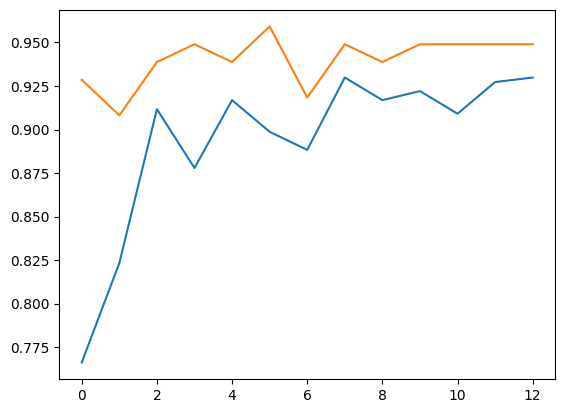

In [28]:
# 훈련과 테스트 데이터의 정확도를 그래프로 확인

plt.plot(train_acc_hist)
plt.plot(val_acc_hist)
plt.show()

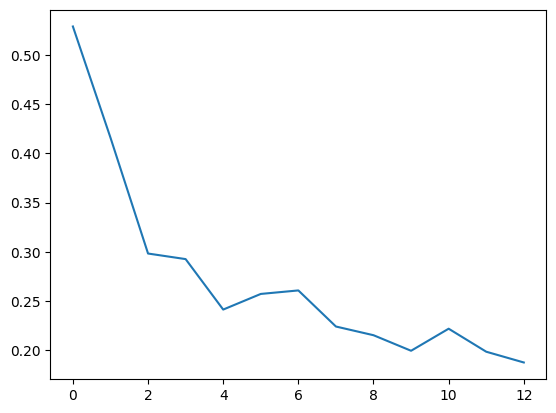

In [29]:
# 훈련 데이터의 오차에 대한 그래프 확인

plt.plot(train_loss_hist)
plt.show()

에포크가 진행될수록 정확도가 높아지면서 100%에 가까워지고 있으며, 오차가 낮아지고 있기 때문에 학습이 잘 되었다고 할 수 있다.

In [30]:
# 예측 이미지 출력을 위한 전처리 함수

def im_convert(tensor):
    image = tensor.clone().detach().numpy()
    image = image.transpose(1,2,0)
    image = image*(np.array((0.5,0.5,0.5)) + np.array((0.5,0.5,0.5)))
    image = image.clip(0,1)
    return image

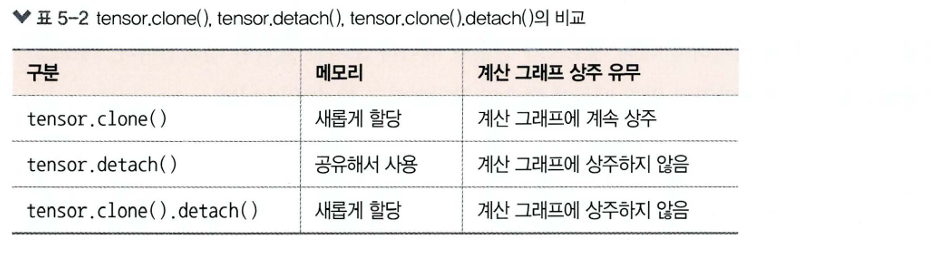

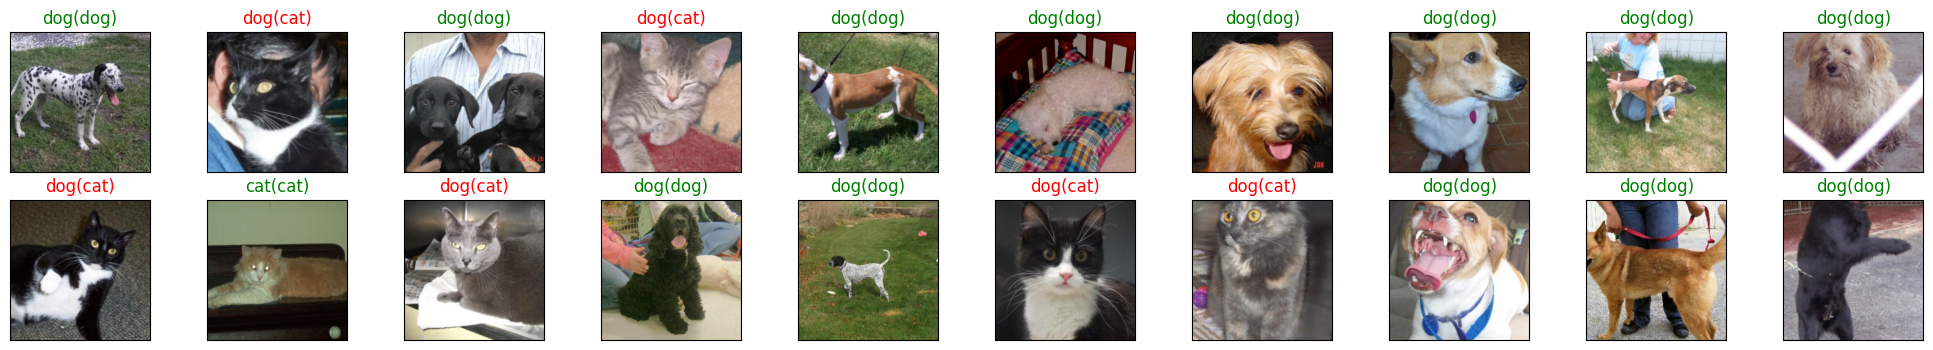

<Figure size 640x480 with 0 Axes>

In [32]:
# 개와 고양이 예측 결과 출력

classes = {0: 'cat', 1: 'dog'}

dataiter = iter(test_loader)
images, labels = next(dataiter)
output = model(images)
_, preds = torch.max(output,1)

fig = plt.figure(figsize=(25,4))
for idx in np.arange(20):
    ax = fig.add_subplot(2, 10, idx+1, xticks=[], yticks=[])
    plt.imshow(im_convert(images[idx]))
    a.set_title(classes[labels[i].item()])
    ax.set_title("{}({})".format(str(classes[preds[idx].item()]),
                                 str(classes[labels[idx].item()])),
                                 color=("green" if preds[idx]==labels[idx] else "red"))
plt.show()
plt.subplots_adjust(bottom=0.2, top=0.6, hspace=0)

### **2. 미세 조정 기법**

**미세 조정(fine-tuning) 기법**은 특성 추출 기법에서 더 나아가 사전 훈련된 모델과 합성곱층, 데이터 분류기의 가중치를 업데이트하여 훈련시키는 방식이다. 특성 추출은 목표 특성을 잘 추출했다는 전제하에 좋은 성능을 낼 수 있다. 만일 특성이 잘못 추출되었다면 미세 조정 기법으로 새로운 이미지 데이터를 사용하여 네트워크의 가중치를 업데이트해서 특성을 다시 추출할 수 있다. 즉, **사전 학습된 모델을 목적에 맞게 재학습시키거나 학습된 가중치의 일부를 재학습시키는 것**이다.

미세 조정 기법은 사전 훈련된 네트워크를 미세 조정하여 분석하려는 데이터셋에 잘 맞도록 모델의 파라미터를 조정하는 기법이다.

미세 조정 기법은 훈련시키려는 데이터셋의 크기와 사전 훈련된 모델에 따라 전략을 세울 수 있다.
- **데이터셋이 크고, 사전 훈련된 모델과 유사성이 작을 경우**: 모델 전체를 재학습
- **데이터셋이 크고, 사전 훈련된 모델과 유사성이 클 경우**: 합성곱층의 뒷부분과 데이터 분류기를 학습
- **데이터셋이 작고 사전 훈련된 모델과 유사성이 작을 경우**: 합성곱층의 일부분과 데이터 분류기를 학습
- **데이터셋이 작고 사전 훈련된 모델과 유사성이 클 경우**: 데이터 분류기만 학습

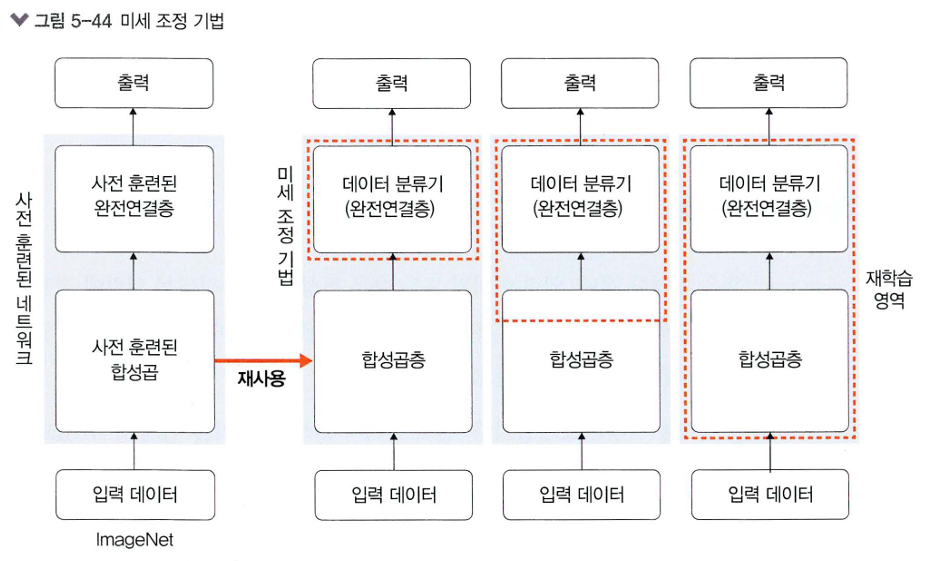

미세 조정은 파라미터 업데이트 과정에서 파라미터에 큰 변화를 주게 되면 과적합 문제가 발생할 수 있기에 정교하고 미세한 파라미터 업데이트가 필요하다.